In [1]:
import sys
import numpy as np
import torch 
# still do preprocessing in scipy
import scipy.sparse as sp
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from importlib import reload
# get UMAP
import umap

# import factor model from beta-dirichlet-factor
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/beta-dirichlet-factor')
import factor_model
reload(factor_model)

2.1.0.dev20230321+cu117
11.7
Tesla V100-PCIE-16GB
2.1.0.dev20230321+cu117
11.7
Tesla V100-PCIE-16GB


<module 'factor_model' from '/gpfs/commons/home/kisaev/Leaflet-private/src/beta-dirichlet-factor/factor_model.py'>

In [2]:
# Append this directory to sys.path
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/clustering/')
import Leaflet_load_cluster_data_03 as llc 

### Settings and Load data

In [3]:
torch.manual_seed(42)

# set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

float_type = { 
    "device" : device, 
    "dtype" : torch.float, # save memory
}

cuda


In [4]:
input_files_folder = '/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/MLCB_Brain_true/FULL/'

cell_types = ['Brain_Non-Myeloid_brain_pericyte','Brain_Non-Myeloid_oligodendrocyte_precursor_cell','Brain_Non-Myeloid_endothelial_cell','Brain_Non-Myeloid_oligodendrocyte',
 'Brain_Non-Myeloid_neuron', 'Brain_Myeloid_macrophage',
 'Brain_Myeloid_microglial_cell', 'Brain_Non-Myeloid_astrocyte']

#ignoring Bergmann_glial_cell since very few cells

# convert data to Leaflet required input formats 
final_data, coo_counts_sparse, coo_cluster_sparse, cell_ids_conversion, junction_ids_conversion = llc.load_cluster_data(
    input_folder = input_files_folder, max_intron_count=5000, celltypes=cell_types, remove_singletons=True, has_genes="yes") 

# add cluster to final_data 
final_data = final_data.merge(junction_ids_conversion, on=["junction_id_index"], how="left")

# get indices (maybe don't need this actually)
indices = (final_data.cell_id_index, final_data.junction_id_index)
indices_np = np.stack(indices)
junc_counts = sp.coo_matrix((final_data.junc_count, indices))
cluster_counts = sp.coo_matrix((final_data.cluster_count, indices))

Reading in data from folder ...
/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/MLCB_Brain_true/FULL/
Finished reading in data from folder ...
Looking at only specific cell types ...['Brain_Non-Myeloid_brain_pericyte', 'Brain_Non-Myeloid_oligodendrocyte_precursor_cell', 'Brain_Non-Myeloid_endothelial_cell', 'Brain_Non-Myeloid_oligodendrocyte', 'Brain_Non-Myeloid_neuron', 'Brain_Myeloid_macrophage', 'Brain_Myeloid_microglial_cell', 'Brain_Non-Myeloid_astrocyte']
Removing singletons ...
Number of junctions before removing singletons:  16190
Number of junctions after removing singletons:  16187
The number of unique cell types in the data is:  8
The number of unique cells in the data is:  7816
The number of unique junctions in the data is:  16188
The maximum junction count was initially:  150346
80
The maximum junction count is now:  4982
The number of junctions in the data is:  15926
The number of cells in the data is:  7816
The number of cell types in the data

In [5]:
cell_index_tensor, junc_index_tensor, my_data = llc.make_torch_data(final_data, **float_type)

The number of cells going into training data is:
7816
7816


/gpfs/commons/home/kisaev/Leaflet-private/src/clustering/Leaflet_load_cluster_data_03.py:45: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at ../aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  ycount_lookup = torch.sparse_coo_tensor(


In [6]:
simple_data = final_data[["cell_id_index", "Cluster", "cell_type", "junction_id_index", "juncratio", "junc_count", "cluster_count",  "junction_id", "gene_id"]]

### Get ready for model training 

In [7]:
if device == torch.device('cuda'):
    torch.set_default_tensor_type('torch.cuda.FloatTensor')

In [8]:
indices = torch.tensor(final_data[['cell_id_index', 'junction_id_index']].to_numpy().T, dtype=torch.long)
values = torch.tensor(final_data['junc_count'].to_numpy(), dtype=torch.float)
# Determine the size of the tensor
num_cells = final_data['cell_id_index'].max() + 1
num_junctions = final_data['junction_id_index'].max() + 1
size = (num_cells, num_junctions)
# Create a sparse tensor
y_tensor = torch.sparse_coo_tensor(indices, values, size)

In [9]:
indices_counts = torch.tensor(final_data[['cell_id_index', 'junction_id_index']].to_numpy().T, dtype=torch.long)
values_counts = torch.tensor(final_data['cluster_count'].to_numpy(), dtype=torch.float)
# Determine the size of the tensor
num_cells_counts = final_data['cell_id_index'].max() + 1
num_junctions_counts = final_data['junction_id_index'].max() + 1
size_counts = (num_cells_counts, num_junctions_counts)
# Create a sparse tensor
total_counts_tensor = torch.sparse_coo_tensor(indices_counts, values_counts, size_counts)

In [10]:
# save full dataset y_tensor and total_counts_tensor 
full_y_tensor = y_tensor
full_total_counts_tensor = total_counts_tensor

In [11]:
cluster_counts

<7816x15926 sparse matrix of type '<class 'numpy.int64'>'
	with 10545293 stored elements in COOrdinate format>

In [12]:
10545293 / (7816*15926)

0.08471637985097658

In [13]:
# how many zeroes in the data compared to total number of values
perc_nonzero = cluster_counts.nnz / (cluster_counts.shape[0] * cluster_counts.shape[1])
print("The percentage of missing values in the intron counts matrix is: ", 1-perc_nonzero)

The percentage of missing values in the intron counts matrix is:  0.9152836201490234


## Evaluate performance on imputation/masking task

In [14]:
# import factor model from beta-dirichlet-factor
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/evaluations')
import masking
from masking import *

# import reload 
from importlib import reload
reload(masking)

<module 'masking' from '/gpfs/commons/home/kisaev/Leaflet-private/src/evaluations/masking.py'>

In [37]:
#1. get masked matrix using intron cluster counts for this mouse brain data 

# same masking percentage for all three matrices but generating three different masks
masking_percs = [0.09, 0.1]
masks_list = []

# get masked matrix for each masking percentage

print("+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")
print("Getting masked matrix for each masking percentage")
print("+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")

for perc_mask in masking_percs:
    print("The masking percentage is: " + str(perc_mask))
    masked_matrix = generate_mask(cluster_counts, mask_percentage = perc_mask, randomize_seed = True)
    masks_list.append(masked_matrix)

#2. get junction and intron cluster count matrices with masked values 
masked_counts = []

print("+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")
print("Getting junction and intron cluster count matrices with masked values")
print("+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")

for i in range(len(masking_percs)):
    print("The masking percentage is: " + str(masking_percs[i]))
    masked_junction_counts, masked_intron_clusts = apply_mask(junc_counts, cluster_counts, masks_list[i])
    # appent masked junction and intron cluster counts to list
    masked_counts.append((masked_junction_counts, masked_intron_clusts))

#3. get input files for factor model (junction and intron cluster sparse tensor)
model_input_files = [] 

print("+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")
print("Getting input files for factor model")
print("+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")

for i in range(len(masking_percs)):
    print("The masking percentage is: " + str(masking_percs[i]))
    masked_junction_counts, masked_intron_clusts = masked_counts[i]
    # get y_tensor and total_counts_tensor via prep_model_input function
    y_tensor, total_counts_tensor = prep_model_input(masked_junction_counts, masked_intron_clusts)
    # append to model_input_files list
    model_input_files.append((y_tensor, total_counts_tensor))

+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Getting masked matrix for each masking percentage
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
The masking percentage is: 0.09
The seed is:  177488
Number of entries (junction-cell pairs) masked:  949076.0
The masking percentage is: 0.1
The seed is:  985210
Number of entries (junction-cell pairs) masked:  1054529.0
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Getting junction and intron cluster count matrices with masked values
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
The masking percentage is: 0.09
The masking percentage is: 0.1
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Getting input files for factor model
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
The masking percentage is: 0.09
The masking percentage is: 0.1


In [38]:
# Now can run factor model on masked data
Ks = [20, 100, 150, 200, 250, 500]
all_Ks_results = {}

# define list of seeds 
seeds = [420, 4003]

for k in Ks:
    
    print("------------------------------------------------")
    print("Running factor model for K = " + str(k))
    print("------------------------------------------------")
    
    # now also iterate over masking percentages 
    for i in range(len(masking_percs)):
        print("The masking percentage is: " + str(masking_percs[i]))
        y_tensor, total_counts_tensor = model_input_files[i]
        # run factor model
        masked_results = factor_model.main(y_tensor, total_counts_tensor, num_initializations=3, use_global_prior=True, K=k, seeds=seeds,loss_plot=False, num_epochs=100, lr = 0.01, save_to_file = False)
        # save results to dictionary
        all_Ks_results[(k, masking_percs[i])] = masked_results

------------------------------------------------
Running factor model for K = 20
------------------------------------------------
The masking percentage is: 0.09
Using prior for a and b per junction to model average behaviour!
Initialization 1 with seed 420
Define the guide
Fit the model
Epoch 0, Loss: 235033598.0961974
Epoch 10, Loss: 221072915.7893912
Epoch 20, Loss: 208264220.88107044
Epoch 30, Loss: 196436393.21311393
Epoch 40, Loss: 185835105.49320576
Epoch 50, Loss: 175962220.92553842
Epoch 60, Loss: 166820566.38317528
Epoch 70, Loss: 158681075.47426298
Epoch 80, Loss: 151009010.37294137
Epoch 90, Loss: 143842243.4688066
Sample from the guide (posterior)
Extract the latent variables
Initialization 2 with seed 4003
Define the guide
Fit the model
Epoch 0, Loss: 230952740.26306814
Epoch 10, Loss: 217318281.37244663
Epoch 20, Loss: 204834288.7819407
Epoch 30, Loss: 193337669.45276862
Epoch 40, Loss: 182803076.18096724
Epoch 50, Loss: 173192423.76079077
Epoch 60, Loss: 164453354.74781

In [39]:
# Get pearson correlation and l1 error between true and inferred parameters (PSI)
masked_perf = []

for k in Ks:
    for perc_mask in masking_percs:
        print("Calculating performance for K = " + str(k) + " and masking percentage = " + str(perc_mask))
        masked_results = all_Ks_results[(k, perc_mask)]        
        for res in masked_results:
            # get seed that was used 
            seed = res['seed']

            # get latent variables
            psi = res['latent_vars']["psi"] # psi is the probability of a junction being used in a cluster
            assign_post=res['latent_vars']["assign"]

            # get K 
            K = psi.shape[0]
            J = psi.shape[1]

            # get scores 
            mask_matrix_used = masks_list[i]
            l1, r, l2, rmse = evaluate_model(junc_counts.toarray(), cluster_counts.toarray(), psi, assign_post, mask_matrix_used)

            # get num epochs trained for 
            nepoch = len(res["losses"])

            # save to list 
            masked_perf.append([seed, l1, r, l2, rmse, K, perc_mask, J, nepoch])

Calculating performance for K = 20 and masking percentage = 0.09


/gpfs/commons/home/kisaev/Leaflet-private/src/evaluations/masking.py:183: RuntimeWarning: invalid value encountered in divide
  true_psi = true_juncs / true_clusts


L1 error:  0.2961899145637805
Spearman correlation:  0.4543230483126042
L2 error:  0.12448214971227176
RMSE:  0.352820279621611
L1 error:  0.29344563079676766
Spearman correlation:  0.4631127240930264
L2 error:  0.12271343927268874
RMSE:  0.35030478054501163
Calculating performance for K = 20 and masking percentage = 0.1
L1 error:  0.2973026497473675
Spearman correlation:  0.4490866528776634
L2 error:  0.1253621991192094
RMSE:  0.35406524698028385
L1 error:  0.2945180511277608
Spearman correlation:  0.45825499206335
L2 error:  0.12353761396108623
RMSE:  0.35147917998237993
Calculating performance for K = 100 and masking percentage = 0.09
L1 error:  0.29354932377671555
Spearman correlation:  0.4681266512855225
L2 error:  0.12231927530857628
RMSE:  0.349741726576307
L1 error:  0.29172006980766574
Spearman correlation:  0.4746113481474968
L2 error:  0.12096438080546777
RMSE:  0.3477993398577228
Calculating performance for K = 100 and masking percentage = 0.1
L1 error:  0.29473801687589635

In [40]:
import pandas as pd 
# make masked_perf a dataframe 
masked_perf_df = pd.DataFrame(masked_perf, columns=["seed", "l1", "r", "l2", "rmse", "K",  "perc_masked" , "J", "num_epochs"])

#### Make plots 

In [41]:
masked_perf_df

,seed,l1,r,l2,rmse,K,perc_masked,J,num_epochs
0,420,0.296190,0.454323,0.124482,0.352820,20,0.09,15926,100
1,4003,0.293446,0.463113,0.122713,0.350305,20,0.09,15926,100
2,420,0.297303,0.449087,0.125362,0.354065,20,0.10,15926,100
3,4003,0.294518,0.458255,0.123538,0.351479,20,0.10,15926,100
4,420,0.293549,0.468127,0.122319,0.349742,100,0.09,15926,100
5,4003,0.291720,0.474611,0.120964,0.347799,100,0.09,15926,100
6,420,0.294738,0.462577,0.123242,0.351058,100,0.10,15926,100
7,4003,0.292966,0.468997,0.121903,0.349146,100,0.10,15926,100
8,420,0.293666,0.468036,0.122310,0.349729,150,0.09,15926,100
9,4003,0.291286,0.476679,0.120660,0.347361,150,0.09,15926,100


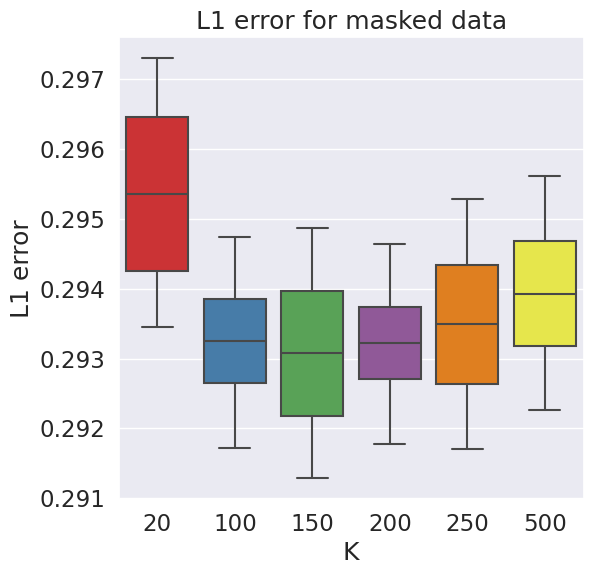

0.29128564575590005


In [59]:
# make boxplot of l1 error for each K and masking percentage
# sns.set_style("whitegrid")
import seaborn as sns
import matplotlib.pyplot as plt 

sns.set_context("paper")
sns.set(font_scale=1.5)
plt.figure(figsize=(6, 6))

# use sns catplot to show K and perc masked
ax = sns.boxplot(x="K", y="l1", data=masked_perf_df, palette="Set1")
ax.set_xlabel("K")
ax.set_ylabel("L1 error")
ax.set_title("L1 error for masked data")
plt.show()
print(masked_perf_df.l1.min())


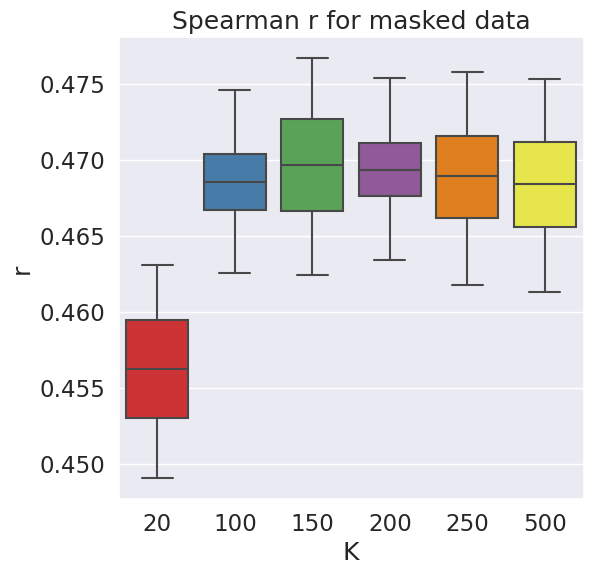

0.4766791970794911


In [60]:
# make boxplot for r 
sns.set_style("whitegrid")
sns.set_context("paper")
sns.set(font_scale=1.5)
plt.figure(figsize=(6, 6))

ax = sns.boxplot(x="K", y="r", data=masked_perf_df, palette="Set1")
ax.set_xlabel("K")
ax.set_ylabel("r")
ax.set_title("Spearman r for masked data")
plt.show()
print(masked_perf_df.r.max())

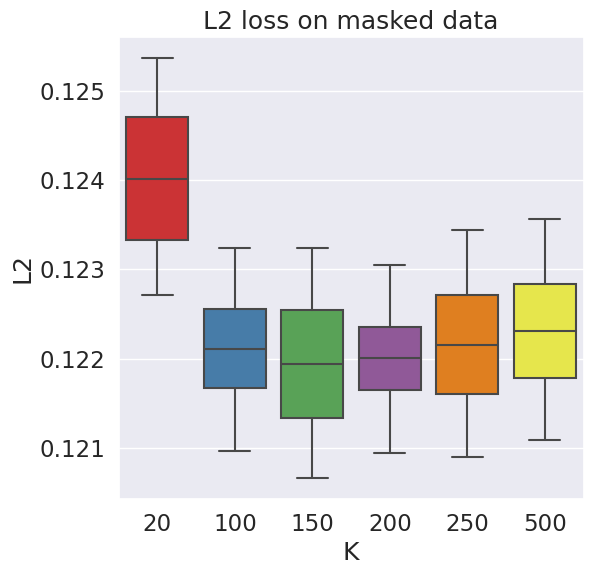

0.4766791970794911


In [61]:
# make boxplot for r 
sns.set_style("whitegrid")
sns.set_context("paper")
sns.set(font_scale=1.5)
plt.figure(figsize=(6, 6))

ax = sns.boxplot(x="K", y="l2", data=masked_perf_df, palette="Set1")
ax.set_xlabel("K")
ax.set_ylabel("L2")
ax.set_title("L2 loss on masked data")
plt.show()
print(masked_perf_df.r.max())

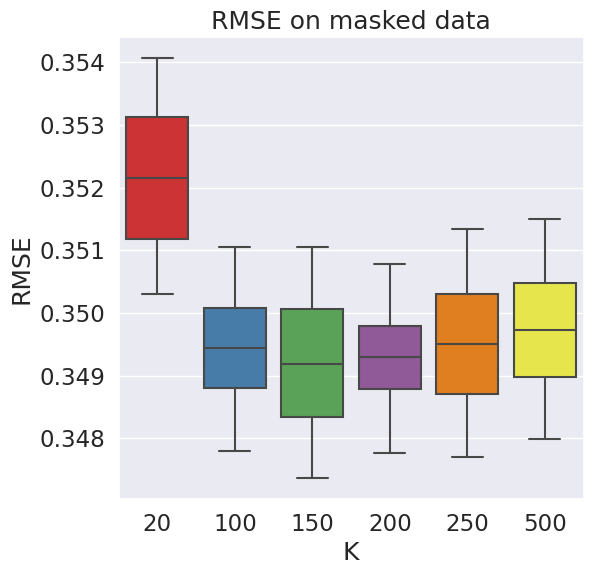

0.3473608435363695


In [62]:
# make boxplot for rmse 
sns.set_style("whitegrid")
sns.set_context("paper")
sns.set(font_scale=1.5)
plt.figure(figsize=(6, 6))

ax = sns.boxplot(x="K", y="rmse", data=masked_perf_df, palette="Set1")
ax.set_xlabel("K")
ax.set_ylabel("RMSE")
ax.set_title("RMSE on masked data")
plt.show()
print(masked_perf_df.rmse.min())

In [46]:
# get median l1 error and pearson r for each K and across all masking percentages
median_l1 = masked_perf_df.groupby(["K"])["l1"].median()
median_r = masked_perf_df.groupby(["K"])["r"].median()
median_l2 = masked_perf_df.groupby(["K"])["l2"].median()
median_rmse = masked_perf_df.groupby(["K"])["rmse"].median()

# find K that gives the lowest l1 error and print it
min_l1 = median_l1.idxmin()
print("The K that gives the lowest median l1 error is: " + str(min_l1))

# find K that gives the lowest l2 error and print it
min_l2 = median_l2.idxmin()
print("The K that gives the lowest median l2 error is: " + str(min_l2))

# find K that gives the highest r and print it
max_r = median_r.idxmax()
print("The K that gives the highest median r is: " + str(max_r))

# find K that gives the lowest rmse and print it
min_rmse = median_rmse.idxmin()
print("The K that gives the lowest median rmse is: " + str(min_rmse))

The K that gives the lowest median l1 error is: 150
The K that gives the lowest median l2 error is: 150
The K that gives the highest median r is: 150
The K that gives the lowest median rmse is: 150


## Run full factor model! 

2.1.0.dev20230321+cu117
11.7
Tesla V100-PCIE-16GB
Using prior for a and b per junction to model average behaviour!
Initialization 1 with seed 3956
Define the guide
Fit the model
Epoch 0, Loss: 269893622.0951891
Epoch 10, Loss: 254153583.71191138
Epoch 20, Loss: 239529797.3975542
Epoch 30, Loss: 226380500.96424365
Epoch 40, Loss: 213970119.65777832
Epoch 50, Loss: 202566831.06010503
Epoch 60, Loss: 192428302.38648182
Epoch 70, Loss: 182622711.10081375
Epoch 80, Loss: 173650788.65778524
Epoch 90, Loss: 164904088.77358788
Epoch 100, Loss: 157029398.80112582
Epoch 110, Loss: 149305309.73445112
Epoch 120, Loss: 141539828.48114926
Epoch 130, Loss: 134350982.7548692
Epoch 140, Loss: 127293928.35813326
Epoch 150, Loss: 120489390.00639132
Epoch 160, Loss: 114267653.30453767
Epoch 170, Loss: 108155502.4853421
Epoch 180, Loss: 102840824.11675763
Epoch 190, Loss: 98002480.04532753
Epoch 200, Loss: 93656038.5808881
Epoch 210, Loss: 89911466.83572224
Epoch 220, Loss: 86718127.73918957
Epoch 230, Los

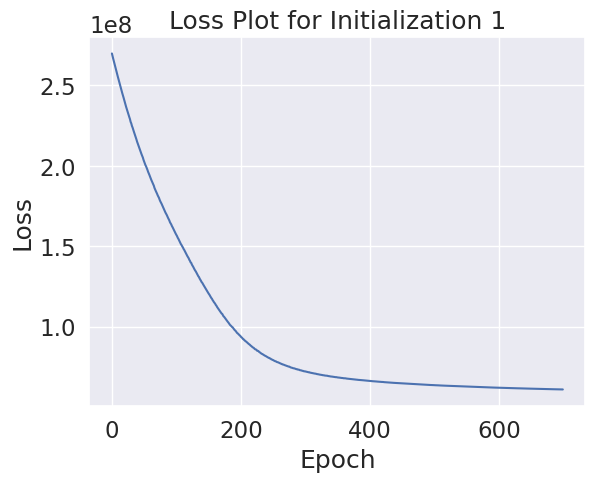

Sample from the guide (posterior)
Extract the latent variables
Initialization 2 with seed 3792
Define the guide
Fit the model
Epoch 0, Loss: 268215097.94354934
Epoch 10, Loss: 252364986.05905443
Epoch 20, Loss: 237954197.70878017
Epoch 30, Loss: 224626439.65649688
Epoch 40, Loss: 212122816.3509466
Epoch 50, Loss: 200970459.37632513
Epoch 60, Loss: 190609609.0761129
Epoch 70, Loss: 180846594.56616354
Epoch 80, Loss: 172164734.21150714
Epoch 90, Loss: 163505509.56148595
Epoch 100, Loss: 155460648.6994581
Epoch 110, Loss: 147640425.5812396
Epoch 120, Loss: 140137559.03009862
Epoch 130, Loss: 132946789.86787596
Epoch 140, Loss: 125692165.53614996
Epoch 150, Loss: 118851276.56054239
Epoch 160, Loss: 112680802.37155339
Epoch 170, Loss: 107097673.9347009
Epoch 180, Loss: 101697531.85422917
Epoch 190, Loss: 96909127.29879999
Epoch 200, Loss: 92903109.74693525
Epoch 210, Loss: 89234239.0444422
Epoch 220, Loss: 86080411.02340038
Epoch 230, Loss: 83322090.10634358
Epoch 240, Loss: 80979899.437756

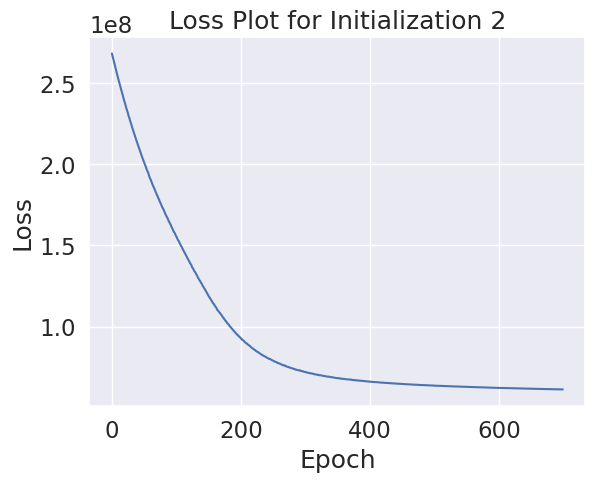

Sample from the guide (posterior)
Extract the latent variables
All initializations complete. Returning results.
------------------------------------------------


In [47]:
reload(factor_model)
best_K = 150 
K = best_K

all_results = factor_model.main(full_y_tensor, full_total_counts_tensor, num_initializations=2, use_global_prior=True, K=K, lr=0.01, loss_plot=True, num_epochs=700, save_to_file = False)

In [48]:
# extract latent variables for just first seed used 
latent_vars = all_results[1]['latent_vars'] 
pi = latent_vars["pi"] # overall contribution of each factor to cell population, one value per k
conc = latent_vars["conc"] # one scaling value 

assign_post = latent_vars["assign"]

psis = latent_vars["psi"] # psi is the probability of a junction being used in a cluster

a = latent_vars["a"] 
b = latent_vars["b"] 
print(a)
print(b)

print("The inferred concentration parameter is: " + str(conc))
print("The inferred pi parameter is: " + str(pi))

[4.7926197  2.8863904  0.85811496 ... 1.0369653  3.055877   2.9782078 ]
[4.3337574 3.5834482 0.860473  ... 3.5090632 3.4576986 2.6626725]
The inferred concentration parameter is: 27.664822
The inferred pi parameter is: [0.00886047 0.08812939 0.00912797 0.02648964 0.00674424 0.00688237
 0.01213395 0.02844771 0.00648869 0.00699956 0.06145481 0.00651359
 0.0062641  0.00615271 0.00662269 0.00612045 0.00677704 0.00641593
 0.03455325 0.00578899 0.00821357 0.00582431 0.0274734  0.00581793
 0.00588381 0.00646896 0.00599639 0.00580879 0.00538696 0.00561482
 0.00546359 0.00560653 0.00574927 0.0199536  0.00544337 0.00771992
 0.01359343 0.00540947 0.00972399 0.00589033 0.01385859 0.00945729
 0.00550874 0.0047427  0.00951931 0.0051455  0.00862162 0.00480922
 0.00459309 0.00652424 0.00574877 0.00685472 0.00459903 0.00478864
 0.00878346 0.00500572 0.0046509  0.00870319 0.00495549 0.00567691
 0.00671229 0.00531128 0.0049173  0.00453391 0.00476376 0.00606648
 0.00544609 0.00664354 0.00420573 0.00646847

### Evaluate latent variables 

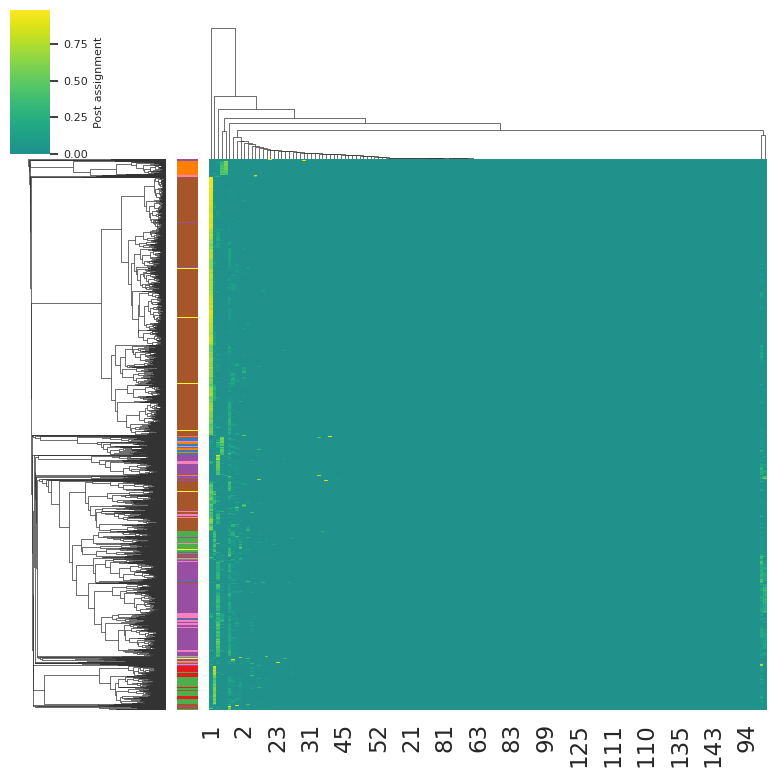

In [49]:
color_palette = sns.color_palette("Set1", n_colors=len(cell_ids_conversion['cell_type'].unique()))
# Create a color bar legend
legend = sns.color_palette(palette=color_palette, as_cmap=True)

# Obtain cell type labels for every cell in the matrix also 
unique_cell_types = cell_ids_conversion['cell_type'].unique()
num_unique_types = len(unique_cell_types)
colors = sns.color_palette('Set1', n_colors=num_unique_types)  # You can use any color palette
cell_types = cell_ids_conversion.cell_type.values

# create colours for each cell type 
cell_type_colors = {cell_type: color for cell_type, color in zip(unique_cell_types, colors)}
row_colors = [cell_type_colors[cell_type] for cell_type in cell_types]

cluster = sns.clustermap(
    data=assign_post,
    method='complete',
    cmap="viridis",
    annot=False,
    fmt=".2f",
    yticklabels=False,
    figsize=(8, 8),
    center=0,
    row_colors=row_colors,  # Apply row colors
    cbar_kws={'label': 'Post assignment'} 
    )
cluster.cax.set_ylabel('Post assignment', size=8)
# Increase font size for color bar tick labels:
cbar_ax = cluster.cax
for label in cbar_ax.yaxis.get_ticklabels():
    label.set_size(8)

In [50]:
# above heatmap is cluster assignment matrix 
# before heatmap we had one factor contributing to a bunch of cells 
# re-save those heatmaps for global prior and no global prior
# with PCA, you always have choice to center first or not, if not - but centering would have an effect, first PC ends up represnting the mean 
# for every gene, could have a PC where the values are always kind of constant for every cell 
# and the loading for the genes would just be their means... 
# can use a PC to model a mean 
# similarly here could just have a factor to represent the mean

The silhouette score for K = 150 is: 0.10193412
The Davies Bouldin score for K = 150 is: 3.2645421687708702


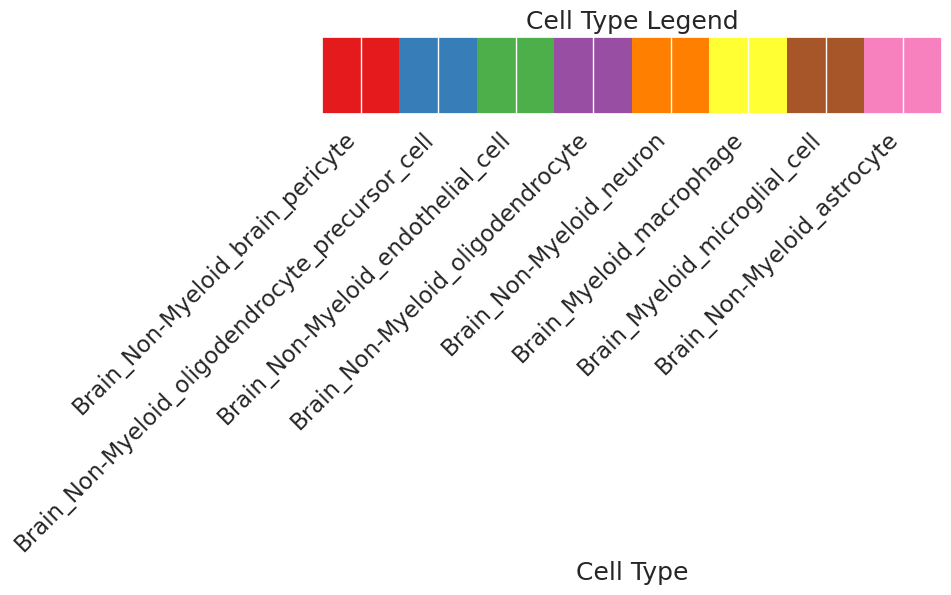

In [51]:
# print cell type color legend seperately
cell_type_colors
# Create a color bar legend
legend = sns.color_palette(palette=color_palette, as_cmap=True)
sns.palplot(color_palette)
plt.title("Cell Type Legend")
# add cell type names to legend
plt.xticks(np.arange(len(unique_cell_types)), unique_cell_types, rotation=45, ha='right')
plt.xlabel("Cell Type")

# let's calculate silhouette score ussing assign_post
ss = silhouette_score(assign_post, cell_types)
# print with K equals K the ss is 
print("The silhouette score for K = " + str(K) + " is: " + str(ss))

# get davies bouldin score
from sklearn.metrics import davies_bouldin_score
dbs = davies_bouldin_score(assign_post, cell_types)
print("The Davies Bouldin score for K = " + str(K) + " is: " + str(dbs))

In [52]:
# make UMAP using average assign_post across seeds and color points by cell_type 
reducer = umap.UMAP()
embedding = reducer.fit_transform(assign_post)

/scratch/ipykernel_123131/908986799.py:6: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(


Text(0, 0.5, 'UMAP 2')

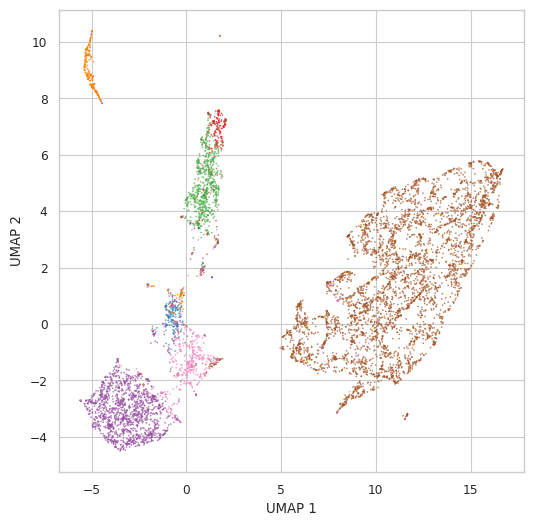

In [53]:
# plot UMAP 
# add whitegrid 
sns.set_style("whitegrid")
sns.set_context("paper")
plt.figure(figsize=(6, 6))
plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    c=[cell_type_colors[cell_type] for cell_type in cell_types],
    s=0.1,
    cmap="Spectral",
)
# xlab 
plt.xlabel("UMAP 1")
# ylab
plt.ylabel("UMAP 2")

([<matplotlib.axis.XTick at 0x7f77c4123a90>,
 [Text(0, 0, 'Brain_Non-Myeloid_brain_pericyte'),
  Text(1, 0, 'Brain_Non-Myeloid_oligodendrocyte_precursor_cell'),
  Text(2, 0, 'Brain_Non-Myeloid_endothelial_cell'),
  Text(3, 0, 'Brain_Non-Myeloid_oligodendrocyte'),
  Text(4, 0, 'Brain_Non-Myeloid_neuron'),
  Text(5, 0, 'Brain_Myeloid_macrophage'),
  Text(6, 0, 'Brain_Myeloid_microglial_cell'),
  Text(7, 0, 'Brain_Non-Myeloid_astrocyte')])

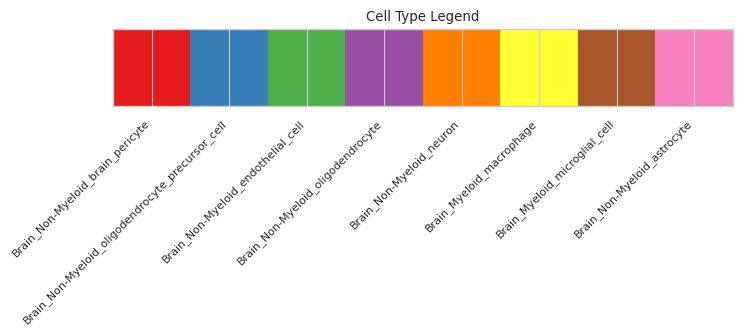

In [54]:
# plot cell_type_colors legend
sns.palplot(color_palette)
plt.title("Cell Type Legend")
# add cell type names to legend
plt.xticks(np.arange(len(unique_cell_types)), unique_cell_types, rotation=45, ha='right', size=8)

[0.551789   0.14372593 0.07474668 0.04631303 0.02939557 0.02223539
 0.02119481 0.01505622 0.01311096 0.01056626]


/scratch/ipykernel_123131/2434076237.py:14: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(


Text(0, 0.5, 'PC 2')

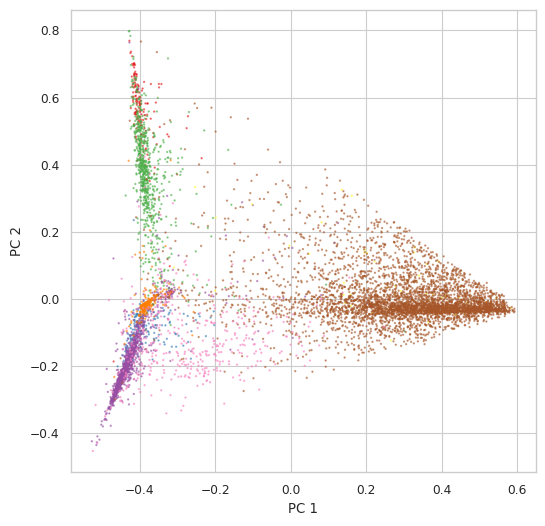

In [55]:
# now run PCA on assign_post 
pca = PCA(n_components=10)
pca.fit(assign_post)
print(pca.explained_variance_ratio_)

pcs = pca.transform(assign_post)
pcs_df = pd.DataFrame(pcs, columns=["PC1", "PC2", "PC3", "PC4", "PC5", "PC6", "PC7", "PC8", "PC9", "PC10"])
cell_types_pcs = cell_ids_conversion["cell_type"]

sns.set_style("whitegrid")
sns.set_context("paper")

plt.figure(figsize=(6, 6))
plt.scatter(
    pcs_df["PC1"],
    pcs_df["PC2"],
    c=[cell_type_colors[cell_type] for cell_type in cell_types],
    s=0.8, alpha=0.5, 
    cmap="Spectral",
)
# xlab 
plt.xlabel("PC 1")
# ylab
plt.ylabel("PC 2")

In [56]:
# for each cell type, get the average factor contribution
cell_type_contribs = {}
for cell_type in unique_cell_types:
    # get indices of cells of this cell type
    cell_type_indices = cell_ids_conversion[cell_ids_conversion["cell_type"] == cell_type].cell_id_index
    # get average factor contribution for these cells
    cell_type_contribs[cell_type] = assign_post[cell_type_indices].mean(axis=0)

# make a dataframe
cell_type_contribs_df = pd.DataFrame(cell_type_contribs)
cell_type_contribs_df = cell_type_contribs_df.T
cell_type_contribs_df.columns = ["Factor " + str(i) for i in range(K)]

cell_type_contribs_df


,Factor 0,Factor 1,Factor 2,Factor 3,Factor 4,Factor 5,Factor 6,Factor 7,Factor 8,Factor 9,...,Factor 140,Factor 141,Factor 142,Factor 143,Factor 144,Factor 145,Factor 146,Factor 147,Factor 148,Factor 149
Brain_Non-Myeloid_brain_pericyte,0.000432,0.011531,0.000412,0.673023,0.000223,0.000232,0.004232,0.004981,0.000234,0.000305,...,2.863134e-06,0.000004,0.000002,3.969810e-07,4.042008e-07,2.147809e-06,8.105532e-07,1.574738e-07,1.958540e-07,1.386154e-07
Brain_Non-Myeloid_oligodendrocyte_precursor_cell,0.000393,0.034642,0.000446,0.006324,0.000373,0.000411,0.435046,0.145790,0.000285,0.002305,...,1.209328e-06,0.000002,0.000002,5.313664e-07,5.705628e-07,3.201826e-07,2.044210e-07,2.933716e-07,3.311410e-07,3.896435e-07
Brain_Non-Myeloid_endothelial_cell,0.000928,0.018625,0.001441,0.425222,0.000450,0.000360,0.025286,0.004823,0.000322,0.000761,...,2.781513e-06,0.000005,0.000003,1.721359e-06,9.193998e-07,1.312863e-06,1.743410e-06,4.439820e-07,3.425832e-07,7.508643e-07
Brain_Non-Myeloid_oligodendrocyte,0.002958,0.012894,0.003537,0.009702,0.001656,0.002875,0.033616,0.299904,0.000360,0.004878,...,4.374823e-06,0.000004,0.000002,2.106067e-06,6.876923e-06,2.566277e-06,2.031504e-06,1.503668e-06,4.249353e-07,5.248795e-07
Brain_Non-Myeloid_neuron,0.000547,0.006342,0.000667,0.014971,0.000371,0.007291,0.379919,0.028932,0.000224,0.003877,...,9.386062e-06,0.000002,0.000002,1.834340e-06,9.114696e-07,1.595825e-06,3.079422e-07,1.032648e-06,1.900311e-07,5.487963e-07
Brain_Myeloid_macrophage,0.001015,0.640458,0.017147,0.094545,0.000168,0.000259,0.003302,0.015721,0.000326,0.000304,...,4.107946e-07,0.000001,0.000001,3.059681e-07,5.288168e-07,3.942320e-07,2.139306e-07,6.770517e-08,9.227595e-08,9.644801e-08
Brain_Myeloid_microglial_cell,0.003866,0.667195,0.015353,0.057012,0.000235,0.000273,0.002410,0.034123,0.000224,0.000439,...,2.005008e-06,0.000002,0.000003,2.419598e-06,7.219248e-07,7.235454e-07,8.072554e-07,5.288236e-07,2.838031e-07,4.166961e-07
Brain_Non-Myeloid_astrocyte,0.003959,0.157944,0.003062,0.045373,0.000692,0.000670,0.134258,0.295986,0.000392,0.026210,...,6.223843e-06,0.000004,0.000018,2.047231e-06,1.815959e-06,4.030350e-06,1.659459e-06,1.028968e-06,1.270343e-06,1.033066e-06


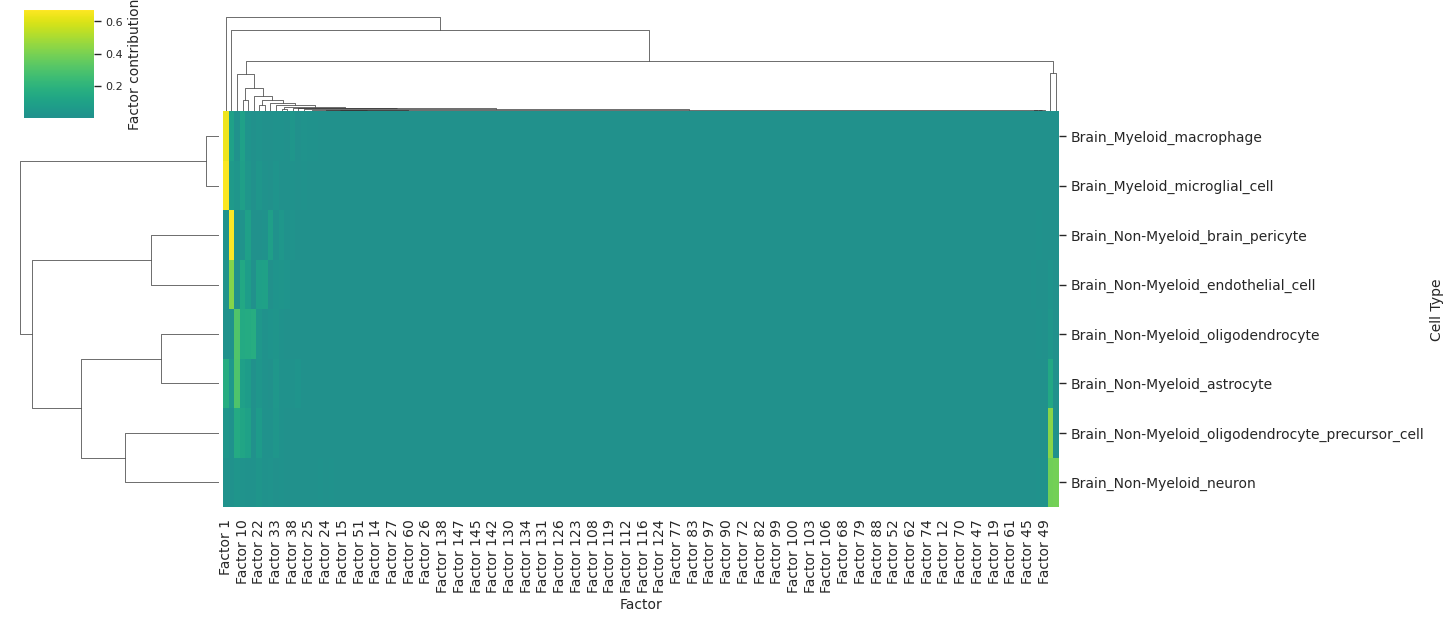

In [57]:
# plot clustermap 
sns.set_style("whitegrid")
sns.set_context("paper")
cluster = sns.clustermap(
    data=cell_type_contribs_df,
    method='complete',
    cmap="viridis",
    annot=False,
    # make font size smaller
    annot_kws={"size": 10},
    yticklabels=True,
    figsize=(14, 6),
    center=0,
    cbar_kws={'label': 'Factor contribution'} 
    )
# increase font of everything 
cluster.ax_heatmap.tick_params(labelsize=10)
cluster.ax_heatmap.set_xlabel('Factor', size=10)
cluster.ax_heatmap.set_ylabel('Cell Type', size=10)
cluster.cax.set_ylabel('Factor contribution', size=10)
# Increase font size for color bar tick labels:
cbar_ax = cluster.cax
for label in cbar_ax.yaxis.get_ticklabels():
    label.set_size(8)